# Рабочая тетрадь: введение в PyTorch

**Формат работы:** выполняйте задания прямо в ячейках ноутбука. После каждого блока есть практические задания и свернутые подсказки с решениями. Сначала попробуйте выполнить самостоятельно, затем откройте подсказку для самопроверки.

**Что нужно сдать:** заполненный `.ipynb`-файл с выполненными ячейками, краткими выводами и индивидуальным вариантом в конце тетради.


## Цели занятия

После выполнения рабочей тетради студент должен уметь:

1. создавать и преобразовывать тензоры PyTorch;
2. выполнять операции над тензорами и понимать broadcasting;
3. использовать `autograd` для вычисления градиентов;
4. описывать простую нейронную сеть через `torch.nn`;
5. работать с `Dataset` и `DataLoader`;
6. запускать базовый цикл обучения и оценивать качество модели;
7. адаптировать модель под новую задачу с помощью заморозки слоев.


## Правила оформления

- В ячейках с пометкой `TODO` замените пропуски своим кодом.
- В текстовых ячейках «Вывод» напишите 1–3 предложения по результатам эксперимента.
- Свернутые блоки «Подсказка / решение» открывайте только после самостоятельной попытки.
- Для воспроизводимости используйте `torch.manual_seed(...)`, где это требуется.


## 1. Tensors
`Тензоры` — это специализированная структура данных, очень похожая на массивы и матрицы. В `PyTorch` мы используем тензоры для кодирования входных и выходных данных модели, а также её параметров.

Тензоры похожи на массивы `ndarray` из `NumPy`, за исключением того, что тензоры могут работать на графических процессорах или других аппаратных ускорителях.

### Инициализация тензора

In [ ]:
import torch
import numpy as np
import math

# Create a tensor directly from data
x = torch.tensor([[1, 2], [3, 4]], dtype=torch.float32)
print("x:", x)

# Create a tensor of zeros
y = torch.zeros(2, 2)
print("y:", y)

# Create a tensor of ones
z = torch.ones(2, 2)
print("z:", z)

# Create a random tensor
w = torch.rand(2, 2)
print("w:", w)

# Create a tensor from a NumPy array
np_array = np.array([1,2,3])
x_np = torch.from_numpy(np_array)
print("x_np:", x_np)

x: tensor([[1., 2.],
        [3., 4.]])
y: tensor([[0., 0.],
        [0., 0.]])
z: tensor([[1., 1.],
        [1., 1.]])
w: tensor([[0.7249, 0.9294],
        [0.4014, 0.5678]])
x_np: tensor([1, 2, 3])


### Атрибуты тензора


In [ ]:
tensor = torch.tensor([[1, 2, 3], [3, 4, 5]]).to(torch.float32)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")

Shape of tensor: torch.Size([2, 3])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


### Операции над тензорами



In [ ]:
# Переместите тензор на графический процессор, если это возможно.
print(tensor)
if torch.cuda.is_available():
  tensor = tensor.to("cuda")
print(tensor)

# Стандартная индексация и нарезка данных, аналогичные NumPy.
tensor = torch.tensor([[1,2,3], [3,4,5]])
print("First row: ", tensor[0])
print("First column: ", tensor[:,0])

tensor([[1., 2., 3.],
        [3., 4., 5.]])
tensor([[1., 2., 3.],
        [3., 4., 5.]], device='cuda:0')
First row:  tensor([1, 2, 3])
First column:  tensor([1, 3])


In [ ]:
# Умножение матриц
tensor = torch.ones(3, 3)
y1 = tensor @ tensor.T
y2 = tensor.matmul(tensor.T)
print("y1: ", y1)
print("y2: ", y2)

y1:  tensor([[3., 3., 3.],
        [3., 3., 3.],
        [3., 3., 3.]])
y2:  tensor([[3., 3., 3.],
        [3., 3., 3.],
        [3., 3., 3.]])


In [ ]:
# Поэлементное умножение
z1 = tensor * tensor
z2 = tensor.mul(tensor)
print("z1: ", z1)
print("z2: ", z2)

z1:  tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])
z2:  tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])


In [ ]:
# общие функции
a = torch.rand(2, 4) * 2 - 1
print(a)
print('Common functions:')
print(torch.abs(a))
print(torch.ceil(a))
print(torch.floor(a))
print(torch.clamp(a, -0.5, 0.5))

# Пазмерность
a = torch.arange(4.)
a_reshaped = torch.reshape(a, (2, 2))
b = torch.tensor([[0, 1], [2, 3]])
b_reshaped =torch.reshape(b, (-1,))
print("a", a)
print("a_reshaped", a_reshaped)
print("b", b)
print("b_reshaped", b_reshaped)


tensor([[-0.3314,  0.4224, -0.8316, -0.3587],
        [ 0.5632,  0.8169, -0.5527,  0.1854]])
Common functions:
tensor([[0.3314, 0.4224, 0.8316, 0.3587],
        [0.5632, 0.8169, 0.5527, 0.1854]])
tensor([[-0., 1., -0., -0.],
        [1., 1., -0., 1.]])
tensor([[-1.,  0., -1., -1.],
        [ 0.,  0., -1.,  0.]])
tensor([[-0.3314,  0.4224, -0.5000, -0.3587],
        [ 0.5000,  0.5000, -0.5000,  0.1854]])
a tensor([0., 1., 2., 3.])
a_reshaped tensor([[0., 1.],
        [2., 3.]])
b tensor([[0, 1],
        [2, 3]])
b_reshaped tensor([0, 1, 2, 3])


### Tensor Broadcasting

In [ ]:
x1 = torch.tensor([[1, 2, 3], [3, 4, 5]])
x2 = torch.tensor([2,2,2])
x1x2 = x1 * x2

print(x1x2)
print("x1.shape", x1.shape)
print("x2.shape", x2.shape)
print("x1x2.shape", x1x2.shape)

tensor([[ 2,  4,  6],
        [ 6,  8, 10]])
x1.shape torch.Size([2, 3])
x2.shape torch.Size([3])
x1x2.shape torch.Size([2, 3])


### Практика 1. Тензоры и broadcasting

Создайте матрицу `A` размера `3×4` со значениями от 1 до 12. Затем:

1. преобразуйте ее к типу `float32`;
2. найдите среднее значение по каждому столбцу;
3. вычтите вектор средних из исходной матрицы с помощью broadcasting;
4. проверьте, что среднее по столбцам стало близко к нулю.


In [ ]:
import torch

torch.manual_seed(42)
A = torch.arange(1, 13, dtype=torch.float32).reshape(3, 4)
col_mean = A.mean(dim=0)
A_centered = A - col_mean
check = A_centered.mean(dim=0)

print("A =", A)
print("Средние по столбцам =", col_mean)
print("Центрированная матрица =", A_centered)
print("Проверка =", check)

A = tensor([[ 1.,  2.,  3.,  4.],
        [ 5.,  6.,  7.,  8.],
        [ 9., 10., 11., 12.]])
Средние по столбцам = tensor([5., 6., 7., 8.])
Центрированная матрица = tensor([[-4., -4., -4., -4.],
        [ 0.,  0.,  0.,  0.],
        [ 4.,  4.,  4.,  4.]])
Проверка = tensor([0., 0., 0., 0.])


<details>
<summary><strong>Подсказка / решение</strong></summary>

```python
import torch

torch.manual_seed(42)
A = torch.arange(1, 13, dtype=torch.float32).reshape(3, 4)
col_mean = A.mean(dim=0)
A_centered = A - col_mean
check = A_centered.mean(dim=0)

print("A =", A)
print("Средние по столбцам =", col_mean)
print("Центрированная матрица =", A_centered)
print("Проверка =", check)
```

Ключевая идея: `col_mean` имеет форму `(4,)`, поэтому PyTorch автоматически «растягивает» его по строкам матрицы `A`.
</details>


**Вывод:** запишите, как broadcasting помог выполнить вычитание без цикла.


## 2. Автоматическое дифференцирование



— Вместо ручного вычисления обратного распространения ошибки, система автоматического дифференцирования выполняет обратное распространение ошибки полностью механическим способом.

— Система автоматического дифференцирования преобразует программу в последовательность примитивных операций, имеющих заданные процедуры для вычисления производных.

### Различие понятий

- **Обратное распространение ошибки**: математический алгоритм, используемый для вычисления градиента.

- **Автоматическое дифференцирование (AutoDiff)**: любое программное обеспечение, реализующее обратное распространение ошибки.

- Примеры: Autograd, TensorFlow, PyTorch, Jax и др.

- **Обратное дифференцирование**: метод эффективного получения точных производных путем сохранения информации при движении вперед, которую можно повторно использовать при движении назад.



### 2.1 Autograd

* [Autograd](https://github.com/HIPS/autograd) — это пакет Python для автоматического дифференцирования.

Из репозитория Autograd на Github:

* Autograd может автоматически дифференцировать нативный код Python и Numpy.

* Он может обрабатывать большой набор функций Python, включая циклы, условные операторы (if/else), рекурсию и замыкания.

* Он также может вычислять производные высшего порядка.

* Он использует обратное дифференцирование (также известное как обратное распространение ошибки), поэтому он может эффективно вычислять градиенты скалярных функций относительно аргументов в виде массивов.

In [ ]:
import autograd.numpy as jnp  # Import thinly-wrapped numpy
from autograd import grad  # По сути, это единственная необходимая вам функция автоматического градиента.

In [ ]:
# Определите функцию, используя Python и NumPy (с помощью autograd):
def tanh(x):
    y = jnp.exp(-x)
    return (1.0 - y) / (1.0 + y)


# Создайте *функцию*, которая вычисляет градиент функции tanh.
grad_tanh = grad(tanh)

# Вычислите градиент в точке x = 1,0.
print(grad_tanh(1.0))

# Сравните с численным градиентом, вычисленным с использованием конечных разностей.
print((tanh(1.0001) - tanh(0.9999)) / 0.0002)

0.39322386648296376
0.39322386636453377


### 2.2 Автоматическое дифференцирование в PyTorch

Для вычисления градиентов функции потерь PyTorch имеет встроенный механизм дифференцирования `torch.autograd`, который динамически отслеживает вычисления во время выполнения. Он поддерживает автоматическое вычисление градиента для любого вычислительного графа.

— На прямом проходе `torch.autograd` выполняет запрошенную операцию для вычисления результирующего тензора. Для каждой примитивной операции данные и функция градиента операции хранятся в вычислительном графе.

— На обратном проходе `torch.autograd` вычисляет градиенты, используя функцию градиента каждой примитивной операции, и накапливает градиенты с помощью правила цепочки.

Рассмотрим однослойную нейронную сеть, представленную ниже:

In [ ]:
import torch

x = torch.ones(5)  # input tensor
y = torch.zeros(3)  # expected output
w = torch.randn(5, 3, requires_grad=True)
b = torch.randn(3, requires_grad=True)
z = torch.matmul(x, w)+b
loss = torch.nn.functional.binary_cross_entropy_with_logits(z, y)

Приведённый выше код определяет следующий вычислительный граф:

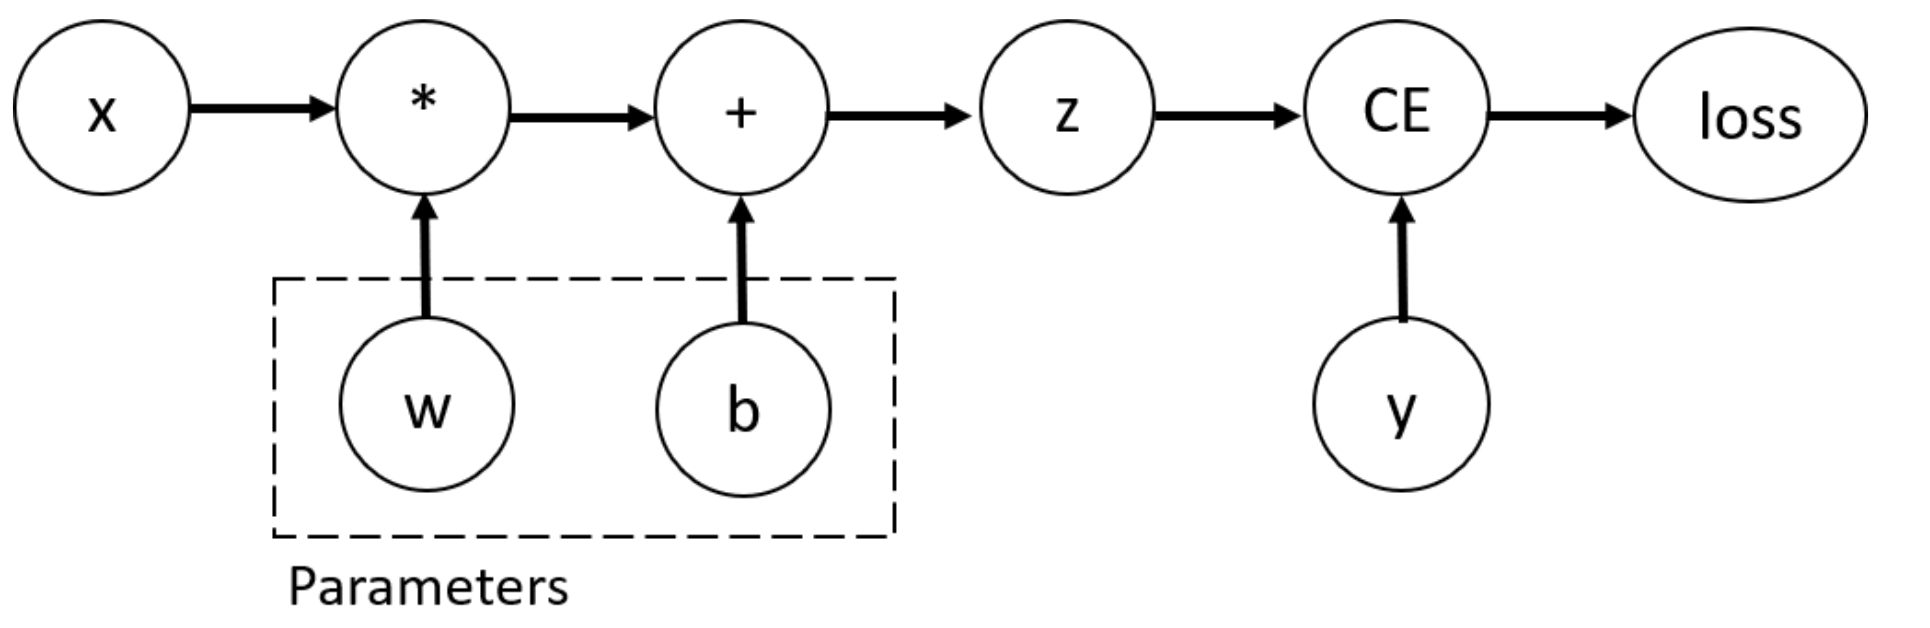

Источник изображения: https://pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html

Нам необходимо вычислить градиенты функции потерь относительно переменных `w` и `b`, поэтому мы установили свойство `requires_grad` для этих тензоров.

**Вычисление градиентов**: Чтобы вычислить `dw` и `db`, мы вызываем `loss.backward()` и получаем значения из `w.grad` и `b.grad`.


In [ ]:
loss.backward()
print(w.grad)
print(b.grad)

tensor([[0.3313, 0.0626, 0.2530],
        [0.3313, 0.0626, 0.2530],
        [0.3313, 0.0626, 0.2530],
        [0.3313, 0.0626, 0.2530],
        [0.3313, 0.0626, 0.2530]])
tensor([0.3313, 0.0626, 0.2530])


**Отключение отслеживания градиента**: Когда модель обучена и мы хотим выполнить только вывод на тестовых данных, нам нужны только прямые вычисления в сети. Мы можем отключить отслеживание градиента, заключив код вычислений в блок `torch.no_grad()`. Это поможет уменьшить потребление памяти для вычислений. Другой случай, когда может потребоваться отключить отслеживание градиента, — это пометить некоторые параметры нейронной сети как замороженные.

In [ ]:
z = torch.matmul(x, w)+b
print(z.requires_grad)

with torch.no_grad():
    z = torch.matmul(x, w)+b
print(z.requires_grad)

True
False


### Практика 2. Autograd

Задайте скалярную функцию

\[
f(x)=3x^2-2x+5
\]

Вычислите значение функции и производную в точке `x = 4` с помощью PyTorch.


In [ ]:
import torch

x = torch.tensor(4.0, requires_grad=True)
y = 3 * x**2 - 2 * x + 5
y.backward()

print("f(x) =", y.item())      # 45.0
print("f'(x) =", x.grad.item()) # 22.0

f(x) = 45.0
f'(x) = 22.0


<details>
<summary><strong>Подсказка / решение</strong></summary>

```python
import torch

x = torch.tensor(4.0, requires_grad=True)
y = 3 * x**2 - 2 * x + 5
y.backward()

print("f(x) =", y.item())      # 45.0
print("f'(x) =", x.grad.item()) # 22.0
```

Аналитически: `f'(x)=6x-2`, значит `f'(4)=22`.
</details>


**Вывод:** сравните автоматический градиент с аналитическим расчетом.


## 3. Создание простой нейронной сети

In [ ]:
# Создайте экземпляр нейронной сети.
import torch.nn as nn
import torch.optim as optim

# Определите нейронную сеть.
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(2, 8, bias=False)
        self.fc2 = nn.Linear(8, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

net = SimpleNet()
print(net)

SimpleNet(
  (fc1): Linear(in_features=2, out_features=8, bias=False)
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)


In [ ]:

# Определите функцию потерь и оптимизатор.
criterion = nn.MSELoss()
optimizer = optim.SGD(net.parameters(), lr=0.01)

# Подготовьте фиктивные данные и метки.
data = torch.tensor([[1., 2.], [3., 4.]], dtype=torch.float32)
labels = torch.tensor([[0.], [1.]], dtype=torch.float32)

# Обучите нейронную сеть
for epoch in range(500):
    # Forward pass
    outputs = net(data)  # эквивалентно `outputs = net.forward(data)`
    loss = criterion(outputs, labels)

    # ВАЖНО. Обнулите градиенты.
    optimizer.zero_grad()

    # Backward pass
    loss.backward()
    optimizer.step()

    # Вывести сумму потерь за эту эпоху.
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}/{500}], Loss: {loss.item():.4f}")


Epoch [100/500], Loss: 0.0546
Epoch [200/500], Loss: 0.0310
Epoch [300/500], Loss: 0.0173
Epoch [400/500], Loss: 0.0095
Epoch [500/500], Loss: 0.0052


### Практика 3. Мини-сеть для регрессии

Создайте небольшой набор данных `X`, `y`, где `y = 2x + 1 + шум`. Обучите линейную модель `nn.Linear(1, 1)` в течение 200 эпох и выведите найденные параметры.


In [ ]:
# TODO: обучите простую модель линейной регрессии
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)
X = torch.linspace(-3, 3, 100).reshape(-1, 1)
y = 2 * X + 1 + 0.2 * torch.randn_like(X)

model = nn.Linear(1, 1)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.05)

for epoch in range(200):
    optimizer.zero_grad()
    pred = model(X)
    loss = criterion(pred, y)
    loss.backward()
    optimizer.step()

print("weight =", model.weight.item())
print("bias =", model.bias.item())
print("loss =", loss.item())


weight = 1.9980348348617554
bias = 1.0119526386260986
loss = 0.038516126573085785


## 4. PyTorch Datasets and DataLoaders

Наборы данных (Datasets) и загрузчики данных (DataLoaders) — это важные компоненты для обработки данных в PyTorch. Набор данных представляет собой коллекцию данных, а загрузчик данных помогает эффективно загружать данные партиями во время обучения.

В этом примере мы будем использовать набор данных FashionMNIST, который содержит 60 000 обучающих изображений и 10 000 тестовых изображений 10 различных предметов одежды.

In [ ]:
import torchvision
import torchvision.transforms as transforms

# Определение преобразований данных
transform = transforms.Compose([
    transforms.Resize(28),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load the FashionMNIST dataset
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)


print("Num training examples: {}".format(len(train_dataset)))
print("Num test examples: {}".format(len(test_dataset)))

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 214kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.99MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.2MB/s]

Num training examples: 60000
Num test examples: 10000


In [ ]:
print(train_dataset)
x, y = train_dataset[0]
print("x.shape", x.shape)
print("y", y)

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               Resize(size=28, interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )
x.shape torch.Size([1, 28, 28])
y 9


In [ ]:
# Создайте загрузчики данных для обучающего и тестового наборов данных.
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=512, shuffle=True, num_workers=2
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=512, shuffle=False, num_workers=2
)

# Список меток классов
classes = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

### Практика 4. Dataset и DataLoader

Создайте собственный датасет из двух тензоров `features` и `targets`, затем сформируйте `DataLoader` с размером батча 8 и выведите первые два батча.


In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

features = torch.randn(40, 5)
targets = torch.randint(0, 3, (40,))
dataset = TensorDataset(features, targets)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

for batch_idx, (xb, yb) in enumerate(loader):
    print("batch", batch_idx, xb.shape, yb.shape)
    if batch_idx == 1:
        break

batch 0 torch.Size([8, 5]) torch.Size([8])
batch 1 torch.Size([8, 5]) torch.Size([8])


<details>
<summary><strong>Подсказка / решение</strong></summary>

```python
import torch
from torch.utils.data import TensorDataset, DataLoader

features = torch.randn(40, 5)
targets = torch.randint(0, 3, (40,))
dataset = TensorDataset(features, targets)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

for batch_idx, (xb, yb) in enumerate(loader):
    print("batch", batch_idx, xb.shape, yb.shape)
    if batch_idx == 1:
        break
```

`DataLoader` разбивает данные на мини-батчи, что удобно для обучения нейронных сетей.
</details>


**Вывод:** укажите, почему перемешивание `shuffle=True` полезно при обучении.


## 5. Визуализация примеров из набора данных FashionMNIST

torch.Size([512, 1, 28, 28])
torch.Size([512])


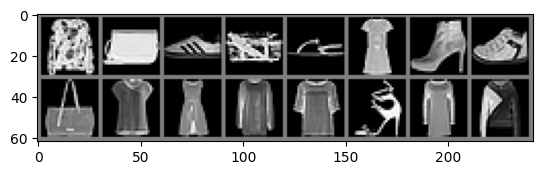

Shirt -- Bag -- Sneaker -- Bag -- Sandal -- Dress -- Ankle boot -- Sneaker
Bag -- T-shirt/top -- Dress -- Pullover -- Shirt -- Sandal -- Dress -- Pullover


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Функция для денормализации и отображения изображения.
def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()



# Получите пакет обучающих данных.
dataiter = iter(train_loader)
images, labels = next(dataiter)
print(images.shape)
print(labels.shape)

# Отобразите изображения в виде сетки вместе с их подписями.
imshow(torchvision.utils.make_grid(images[:16]))
print(" -- ".join(f"{classes[labels[j]]}" for j in range(8)))
print(" -- ".join(f"{classes[labels[j]]}" for j in range(8,16)))

После загрузки набора данных и создания DataLoader мы можем обучить нашу нейронную сеть, используя набор данных FashionMNIST. Давайте изменим наш предыдущий пример SimpleNet, чтобы он обрабатывал изображения размером 28x28 пикселей и 10 выходных классов.

## 6. Training on the CPU = Slow!

In [ ]:
import torch.nn.functional as F

# Define the neural network for FashionMNIST
class FashionMNISTNet(nn.Module):
    def __init__(self):
        super(FashionMNISTNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3)
        self.fc1 = nn.Linear(32 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Создайте экземпляр нейронной сети.
net = FashionMNISTNet()
print(net)

# Определите функцию потерь и оптимизатор.
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9)

# Обучите нейронную сеть, используя набор данных FashionMNIST.
num_epochs = 5
for epoch in range(num_epochs):
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = net(inputs)

        # Compute the loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Update the running loss
        running_loss += loss.item()

    # Print the average loss for this epoch
    avg_loss = running_loss / (i + 1)
    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")
print("Training finished.")

FashionMNISTNet(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=800, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)
Epoch [1/5], Loss: 1.6118
Epoch [2/5], Loss: 0.6648
Epoch [3/5], Loss: 0.5636
Epoch [4/5], Loss: 0.5021
Epoch [5/5], Loss: 0.4614
Training finished.


## 7. Training on the GPU = Faster!

In [ ]:
import torch.nn.functional as F

# Define the neural network for FashionMNIST
class FashionMNISTNet(nn.Module):
    def __init__(self):
        super(FashionMNISTNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3)
        self.fc1 = nn.Linear(32 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# IMPORTANT CODE BELOW
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Create an instance of the neural network
net = FashionMNISTNet()
print(net)

# Move the model to the GPU if available
net.to(device)

# Define the loss function and the optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9)

# Train the neural network using the FashionMNIST dataset
num_epochs = 5
for epoch in range(num_epochs):
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_loader, 0):

        # Move the inputs and labels to the GPU if available
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = net(inputs)

        # Compute the loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Update the running loss
        running_loss += loss.item()

    # Print the average loss for this epoch
    avg_loss = running_loss / (i + 1)
    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")
print("Training finished.")

Using device: cuda
FashionMNISTNet(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=800, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)
Epoch [1/5], Loss: 1.6747
Epoch [2/5], Loss: 0.6528
Epoch [3/5], Loss: 0.5624
Epoch [4/5], Loss: 0.5043
Epoch [5/5], Loss: 0.4604
Training finished.


Теперь, когда мы обучили нашу нейронную сеть, давайте оценим ее производительность на тестовом наборе данных.

In [ ]:
# Test the neural network
correct = 0
total = 0

# Переведите модель в режим оценки.
net.eval()

# Отключить вычисление градиента
with torch.no_grad():
    for inputs, labels in test_loader:

        # Если это возможно, переместите входные данные и метки на графический процессор.
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = net(inputs)

        # Получите прогнозируемый класс
        _, predicted = torch.max(outputs.data, 1)

        # Обновите общее количество выборок и скорректируйте прогнозы.
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Рассчитайте точность.
accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 82.80%


### Практика 5. Оценка качества классификатора

После обучения модели рассчитайте accuracy на тестовой выборке. Дополнительно посчитайте количество правильных ответов по каждому классу.


In [ ]:
correct = 0
total = 0
class_correct = [0 for _ in range(10)]
class_total = [0 for _ in range(10)]

net.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device) if 'device' in globals() else images
        labels = labels.to(device) if 'device' in globals() else labels
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        for label, pred in zip(labels, predicted):
            class_total[label.item()] += 1
            class_correct[label.item()] += int(label.item() == pred.item())

print("Accuracy:", 100 * correct / total)
for i in range(10):
    if class_total[i] > 0:
        print(i, class_correct[i], "/", class_total[i])

Accuracy: 82.8
0 736 / 1000
1 930 / 1000
2 767 / 1000
3 921 / 1000
4 643 / 1000
5 963 / 1000
6 573 / 1000
7 887 / 1000
8 923 / 1000
9 937 / 1000


<details>
<summary><strong>Подсказка / решение</strong></summary>

```python
correct = 0
total = 0
class_correct = [0 for _ in range(10)]
class_total = [0 for _ in range(10)]

net.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device) if 'device' in globals() else images
        labels = labels.to(device) if 'device' in globals() else labels
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        for label, pred in zip(labels, predicted):
            class_total[label.item()] += 1
            class_correct[label.item()] += int(label.item() == pred.item())

print("Accuracy:", 100 * correct / total)
for i in range(10):
    if class_total[i] > 0:
        print(i, class_correct[i], "/", class_total[i])
```

Для FashionMNIST номера классов соответствуют категориям одежды.
</details>


**Вывод:** укажите, какие классы модель распознает лучше/хуже и почему это может происходить.


Неплохо!

Давайте рассмотрим общее количество параметров и количество обучающих параметров в модели:

In [ ]:
total_params = sum(p.numel() for p in net.parameters())
print(f'{total_params:,} total parameters.')
total_trainable_params = sum(
    p.numel() for p in net.parameters() if p.requires_grad)
print(f'{total_trainable_params:,} training parameters.')


116,234 total parameters.
116,234 training parameters.


Теперь, когда у нас есть обученная модель, если мы хотим адаптировать ее к другому набору данных, содержащему всего 5 классов, мы можем заморозить более ранние слои и обучать модель только на последнем полносвязном слое.

In [ ]:
# Freeze earlier layers
for param in net.parameters():
    param.requires_grad = False

n_inputs = net.fc3.in_features
n_classes = 5
net.fc3 = nn.Linear(n_inputs, n_classes)
total_params = sum(p.numel() for p in net.parameters())
print(f'{total_params:,} total parameters.')
total_trainable_params = sum(
    p.numel() for p in net.parameters() if p.requires_grad)
print(f'{total_trainable_params:,} training parameters.')

115,909 total parameters.
325 training parameters.


## 8. Предварительно обученные веса

PyTorch содержит множество предварительно обученных моделей, которые мы можем использовать. Все эти модели были обучены на Imagenet, который содержит миллионы изображений в 1000 категориях. Мы хотим заморозить первые слои этих предварительно обученных моделей и заменить модуль классификации нашим собственным.

API PyTorch для использования предварительно обученных весов: https://pytorch.org/vision/stable/models.html

Подход к использованию предварительно обученной модели распознавания изображений хорошо известен:

1. Загрузка предварительно обученных весов из сети, обученной на большом наборе данных.
2. Замораживание всех весов в нижних (сверточных) слоях.

* Количество замораживаемых слоев может быть скорректировано в зависимости от сходства задачи с большим обучающим набором данных.
3. Замена классификатора (полносвязной) части сети на пользовательский классификатор.

* Количество выходов должно быть установлено равным количеству классов.
4. Обучение только пользовательских слоев классификатора (полносвязных) для задачи.

* Оптимизатор модели для меньшего набора данных.

Мы продемонстрируем пример загрузки предварительно обученной модели Resnet.

In [ ]:
from torchvision import models

model = models.resnet50(pretrained=True)

print(model)

for param in model.parameters():
    param.requires_grad = False

n_inputs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(n_inputs, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, n_classes)
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 176MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
print(sum(p.numel() for p in model.parameters()))
print(sum(p.numel() for p in model.parameters() if p.requires_grad))

24033861
525829


## Индивидуальное задание
Выберите вариант по номеру в журнале. Нужно обучить классификатор FashionMNIST с указанными параметрами и оформить краткий отчет.

**Что сделать:**

1. загрузить FashionMNIST;
2. создать модель с одним скрытым слоем указанного размера;
3. использовать указанную функцию активации, оптимизатор, `learning rate`, `batch_size` и количество эпох;
4. вывести итоговую accuracy на тестовой выборке;
5. построить/вывести матрицу ошибок или таблицу правильных ответов по классам;
6. написать вывод: какие параметры дали хороший/плохой результат и почему.

| Вариант | Скрытых нейронов | Активация | Оптимизатор | LR | Batch size | Эпох |
|---:|---:|---|---|---:|---:|---:|
| 1 | 16 | ReLU | SGD | 0.1 | 16 | 4 |
| 2 | 32 | Tanh | Adam | 0.05 | 32 | 5 |
| 3 | 48 | Sigmoid | RMSprop | 0.03 | 64 | 6 |
| 4 | 64 | LeakyReLU | SGD | 0.01 | 128 | 3 |
| 5 | 96 | ELU | Adam | 0.005 | 256 | 4 |
| 6 | 128 | ReLU | RMSprop | 0.001 | 16 | 5 |
| 7 | 16 | Tanh | SGD | 0.1 | 32 | 6 |
| 8 | 32 | Sigmoid | Adam | 0.05 | 64 | 3 |
| 9 | 48 | LeakyReLU | RMSprop | 0.03 | 128 | 4 |
| 10 | 64 | ELU | SGD | 0.01 | 256 | 5 |
| 11 | 96 | ReLU | Adam | 0.005 | 16 | 6 |
| 12 | 128 | Tanh | RMSprop | 0.001 | 32 | 3 |
| 13 | 16 | Sigmoid | SGD | 0.1 | 64 | 4 |
| 14 | 32 | LeakyReLU | Adam | 0.05 | 128 | 5 |
| 15 | 48 | ELU | RMSprop | 0.03 | 256 | 6 |
| 16 | 64 | ReLU | SGD | 0.01 | 16 | 3 |
| 17 | 96 | Tanh | Adam | 0.005 | 32 | 4 |
| 18 | 128 | Sigmoid | RMSprop | 0.001 | 64 | 5 |
| 19 | 16 | LeakyReLU | SGD | 0.1 | 128 | 6 |
| 20 | 32 | ELU | Adam | 0.05 | 256 | 3 |
| 21 | 48 | ReLU | RMSprop | 0.03 | 16 | 4 |
| 22 | 64 | Tanh | SGD | 0.01 | 32 | 5 |
| 23 | 96 | Sigmoid | Adam | 0.005 | 64 | 6 |
| 24 | 128 | LeakyReLU | RMSprop | 0.001 | 128 | 3 |
| 25 | 16 | ELU | SGD | 0.1 | 256 | 4 |
| 26 | 32 | ReLU | Adam | 0.05 | 16 | 5 |
| 27 | 48 | Tanh | RMSprop | 0.03 | 32 | 6 |
| 28 | 64 | Sigmoid | SGD | 0.01 | 64 | 3 |
| 29 | 96 | LeakyReLU | Adam | 0.005 | 128 | 4 |
| 30 | 128 | ELU | RMSprop | 0.001 | 256 | 5 |


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Укажите свой вариант
variant = 3

# Заполните параметры по таблице
hidden_size = 48
activation_name = "Sigmoid"
optimizer_name = "RMSprop"
learning_rate = 0.03
batch_size = 64
epochs = 6

# 1. Загрузка данных FashionMNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 2. Создание модели с одним скрытым слоем
input_size = 28 * 28
output_size = 10
act_func = nn.Sigmoid()

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(input_size, hidden_size),
    act_func,
    nn.Linear(hidden_size, output_size)
)

# 3. Выбор оптимизатора
optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

# 4. Обучение
model.train()
for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")
print("Training finished.")



Epoch [1/6], Loss: 0.8002
Epoch [2/6], Loss: 0.6756
Epoch [3/6], Loss: 0.6432
Epoch [4/6], Loss: 0.6219
Epoch [5/6], Loss: 0.6134
Epoch [6/6], Loss: 0.6090
Training finished.


In [ ]:
# 5. Оценка качества на тестовой выборке
model.eval()
correct = 0
total = 0
class_correct = [0] * 10
class_total = [0] * 10
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_labels.extend(labels.numpy())
        all_preds.extend(predicted.numpy())
        for i in range(len(labels)):
            lbl = labels[i].item()
            class_total[lbl] += 1
            if predicted[i].item() == lbl:
                class_correct[lbl] += 1

accuracy = 100 * correct / total
print(f"\nИтоговая Accuracy на тестовой выборке: {accuracy:.2f}%")


Итоговая Accuracy на тестовой выборке: 76.45%


In [ ]:
# 6. Таблица правильных ответов по классам
print("\nПравильные ответы по классам:")
for i in range(10):
    print(f"{classes[i]:<12}: {class_correct[i]:3d}/{class_total[i]:3d} ({100*class_correct[i]/max(class_total[i],1):.1f}%)")


Правильные ответы по классам:
T-shirt/top : 609/1000 (60.9%)
Trouser     : 947/1000 (94.7%)
Pullover    : 506/1000 (50.6%)
Dress       : 740/1000 (74.0%)
Coat        : 731/1000 (73.1%)
Sandal      : 843/1000 (84.3%)
Shirt       : 655/1000 (65.5%)
Sneaker     : 880/1000 (88.0%)
Bag         : 841/1000 (84.1%)
Ankle boot  : 893/1000 (89.3%)


<Figure size 1000x800 with 0 Axes>

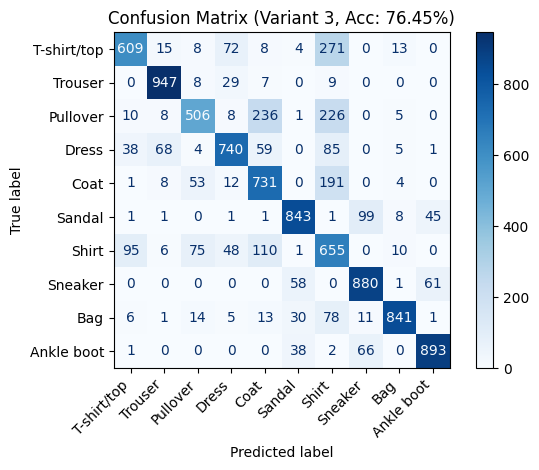

In [ ]:
# 7. Матрица ошибок
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
plt.figure(figsize=(10, 8))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title(f"Confusion Matrix (Variant {variant}, Acc: {accuracy:.2f}%)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Отчет по индивидуальному заданию

- **Вариант:** 3
- **Параметры модели:** hidden=48, activation=Sigmoid, optimizer=RMSprop, LR=0.03, batch=64, epochs=6
- **Итоговая accuracy:** 76,45%
- **Лучше всего распознаются классы:** Trouser, Ankle boot, Sneaker
- **Хуже всего распознаются классы:** Pullover, T-shirt/top, Shirt
- **Вывод:** Активация Sigmoid подвержена проблеме затухания градиентов, что особенно заметно на FashionMNIST с его визуально схожими классами (напр., Shirt/T-shirt, Coat/Pullover). За 6 эпох модель не успевает выучить тонкие грани. RMSprop с LR=0.03 работает стабильнее обычного SGD, но для Sigmoid обычно рекомендуют более низкий LR (~0.005-0.01) или замену на ReLU, чтобы избежать насыщения сигмоиды. Для улучшения результата рекомендуется: увеличить epochs до 15-20, заменить Sigmoid на ReLU или добавить BatchNorm для стабилизации градиентов.
